# 04 - Demand Prediction Agent

This notebook implements the UrbanEV/ST-EVCDP Demand Prediction Agent and produces the demand-side inputs required by the pricing and monitoring agents.

Mentor requirements covered here:

- Time-series train/test split
- Baseline lag model
- Ridge Regression
- XGBRegressor
- MAE, RMSE, R2, and MAPE comparison
- XGBoost feature importance
- Actual vs predicted visualization
- Residual plot and error distribution
- Charger utilization KPI
- Off-peak uplift KPI
- Waiting-time proxy KPI

The agent uses UrbanEV because it contains spatial-temporal occupancy, price, infrastructure, and neighbor-grid signals.


## Assumptions

- The target is future occupancy from the engineered feature table.
- Utilization is calculated as occupancy divided by charger count.
- Dynamic pricing is simulated from predicted utilization, not observed from a randomized field experiment.
- Waiting time is proxied by demand pressure because actual queue wait times are unavailable.


In [38]:
import os
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (12, 6)

BASELINE_PRICE_INR = 15.0
ELASTICITY = -0.2
RANDOM_STATE = 42

FIG_DIR = Path("../outputs/figures")
MODEL_DIR = Path("../outputs/models")
REPORT_DIR = Path("../outputs/reports")
for directory in [FIG_DIR, MODEL_DIR, REPORT_DIR, Path("../data/processed")]:
    directory.mkdir(parents=True, exist_ok=True)

print("Environment ready")


Environment ready


## Load UrbanEV Features

The engineered table combines temporal, spatial, pricing, lag, rolling, and infrastructure features.


In [39]:
df = pd.read_parquet("../data/processed/demand_features.parquet")
df = df.sort_values(["datetime", "grid"]).reset_index(drop=True)

df["utilization"] = (df["occupancy"] / df["count"]).clip(0, 1.5)
df["target_utilization"] = (df["target"] / df["count"]).clip(0, 1.5)

print(df.shape)
df.head()


(2059980, 25)


,timestamp_id,grid,occupancy,datetime,price,count,fast_count,slow_count,area,CBD,dynamic_pricing,hour,dayofweek,month,is_weekend,lag_1,lag_12,lag_24,lag_288,rolling_mean_12,rolling_std_12,target,neighbor_occupancy,utilization,target_utilization
0,289,1000,61,2022-06-20,0.894267,193,0,193,3.08,0,0,0,0,6,0,62.0,64.0,62.0,60.0,63.00,0.738549,65.0,31.800000,0.316062,0.336788
1,289,1009,61,2022-06-20,0.948615,206,0,206,2.33,0,0,0,0,6,0,61.0,63.0,64.0,63.0,62.00,0.738549,64.0,60.166667,0.296117,0.310680
2,289,1011,79,2022-06-20,0.886190,344,0,344,3.41,0,0,0,0,6,0,80.0,83.0,80.0,87.0,81.75,1.288057,82.0,57.400000,0.229651,0.238372
3,289,1015,23,2022-06-20,1.100000,96,0,96,3.16,1,0,0,0,6,0,23.0,21.0,17.0,29.0,21.75,0.866025,24.0,18.500000,0.239583,0.250000
4,289,102,11,2022-06-20,0.924000,30,3,27,0.71,0,0,0,0,6,0,11.0,11.0,11.0,12.0,11.00,0.000000,11.0,1.000000,0.366667,0.366667


## Time-Series Split

The split is chronological, not random, so every model is evaluated on future observations.


In [40]:
features = [
    "price", "count", "fast_count", "slow_count", "area", "CBD",
    "dynamic_pricing", "hour", "dayofweek", "month", "is_weekend",
    "lag_1", "lag_12", "lag_24", "lag_288",
    "rolling_mean_12", "rolling_std_12", "neighbor_occupancy",
]
model_df = df.dropna(subset=features + ["target"]).copy()
model_df["hour_weekend_interaction"] = model_df["hour"] * model_df["is_weekend"]
model_df["util_x_cbd"] = (model_df["occupancy"] / model_df["count"].replace(0, np.nan)).fillna(0) * model_df["CBD"]
model_df["lag_ratio"]  = model_df["lag_1"] / (model_df["rolling_mean_12"] + 1e-6)
split_idx = int(len(model_df) * 0.80)

train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

train_sample = train_df.sample(n=min(200_000, len(train_df)), random_state=RANDOM_STATE)
test_eval = test_df.copy()

X_train = train_sample[features]
y_train = train_sample["target"]
X_test = test_eval[features]
y_test = test_eval["target"]

print("Train period:", train_df["datetime"].min(), "to", train_df["datetime"].max())
print("Test period:", test_df["datetime"].min(), "to", test_df["datetime"].max())
print("Training rows used:", len(train_sample))
print("Test rows:", len(test_eval))


Train period: 2022-06-20 00:00:00 to 2022-07-13 03:55:00
Test period: 2022-07-13 04:00:00 to 2022-07-18 22:55:00
Training rows used: 200000
Test rows: 411996


## Model Training and Comparison

Three models are compared:

- Baseline: lag_12 persistence model
- Ridge Regression: transparent linear baseline
- XGBRegressor: nonlinear gradient-boosted tree model


In [41]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def evaluate_model(name, y_true, y_pred):
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
        "MAPE_percent": mape(y_true, y_pred),
    }


predictions = {}
predictions["Baseline_lag_12"] = test_eval["lag_12"].clip(lower=0, upper=test_eval["count"] * 1.5)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
predictions["Ridge_Regression"] = np.clip(
    ridge_model.predict(X_test),
    0,
    test_eval["count"] * 1.5,
)

from xgboost.callback import EarlyStopping

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.75,
    reg_alpha=0.1,
    reg_lambda=1.5,
    min_child_weight=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
    callbacks=[EarlyStopping(rounds=30, save_best=True)],
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)
predictions["XGBRegressor"] = np.clip(
    xgb_model.predict(X_test),
    0,
    test_eval["count"] * 1.5,
)

comparison = pd.DataFrame(
    [evaluate_model(name, y_test, pred) for name, pred in predictions.items()]
).sort_values("RMSE")

comparison.to_csv(REPORT_DIR / "demand_model_comparison.csv", index=False)
joblib.dump(ridge_model, MODEL_DIR / "ridge_demand_model.joblib")
joblib.dump(xgb_model, MODEL_DIR / "xgb_demand_model.joblib")

comparison


,model,MAE,RMSE,R2,MAPE_percent
2,XGBRegressor,1.735433,3.076585,0.984904,14.168461
1,Ridge_Regression,2.369891,4.450786,0.968407,18.999777
0,Baseline_lag_12,3.442599,7.032456,0.921125,22.403639


### Business Interpretation

The model with the lowest RMSE is preferred for tariff decisions because large demand forecast errors can lead to congestion during peaks or unnecessary discounts during low-demand periods. R2 explains how much occupancy variation is captured by the model.


## Feature Importance

XGBoost feature importance shows which demand signals most strongly influence the forecast.


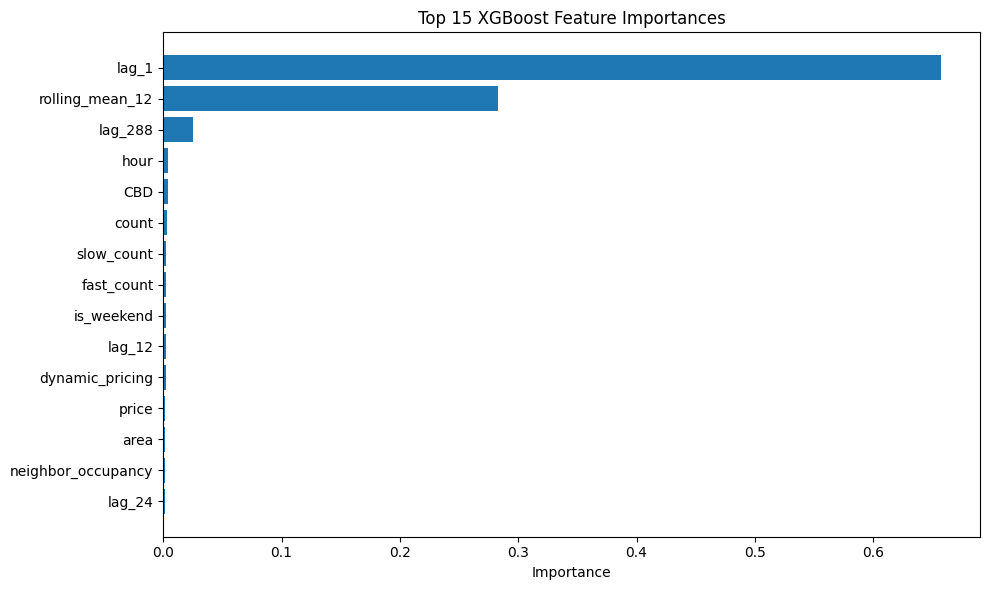

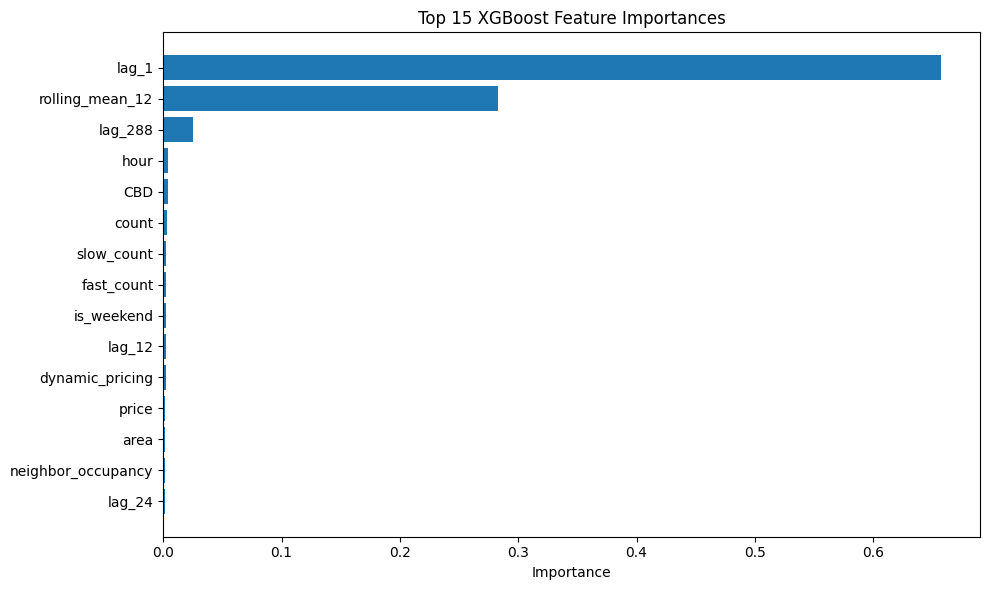

In [42]:
importance = pd.DataFrame(
    {
        "feature": features,
        "importance": xgb_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

top15_importance = importance.head(15).reset_index(drop=True)
top15_importance.to_csv(REPORT_DIR / "xgb_top15_feature_importance.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top15_importance["feature"][::-1], top15_importance["importance"][::-1])
ax.set_title("Top 15 XGBoost Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(FIG_DIR / "xgb_top15_feature_importance.png", dpi=160)
fig


### Business Interpretation

High importance for lag and rolling features means recent utilization is the strongest short-term signal. Neighbor occupancy captures spatial spillover, while price and hour help the pricing agent connect demand patterns to tariff timing.


## Forecast Diagnostics


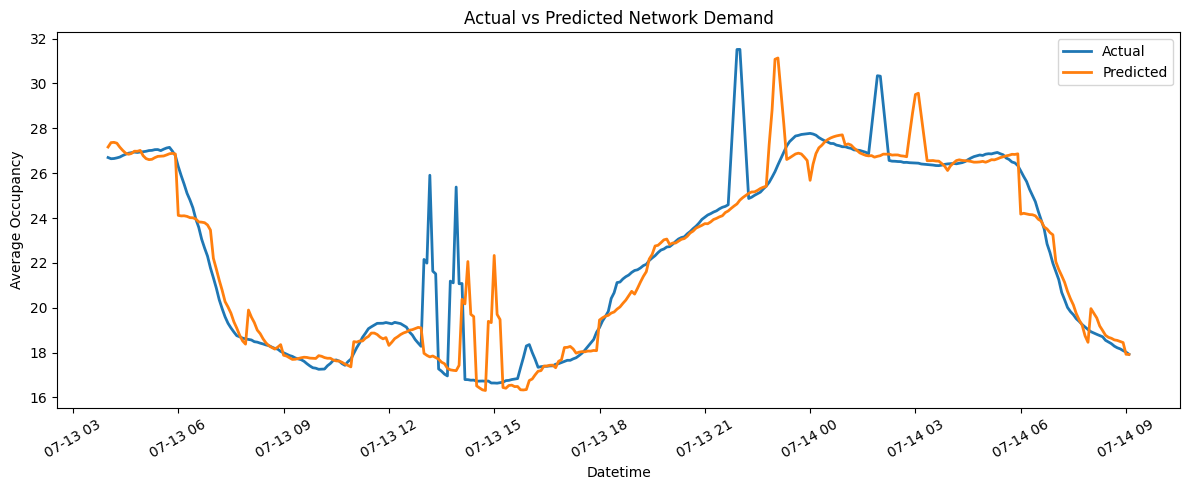

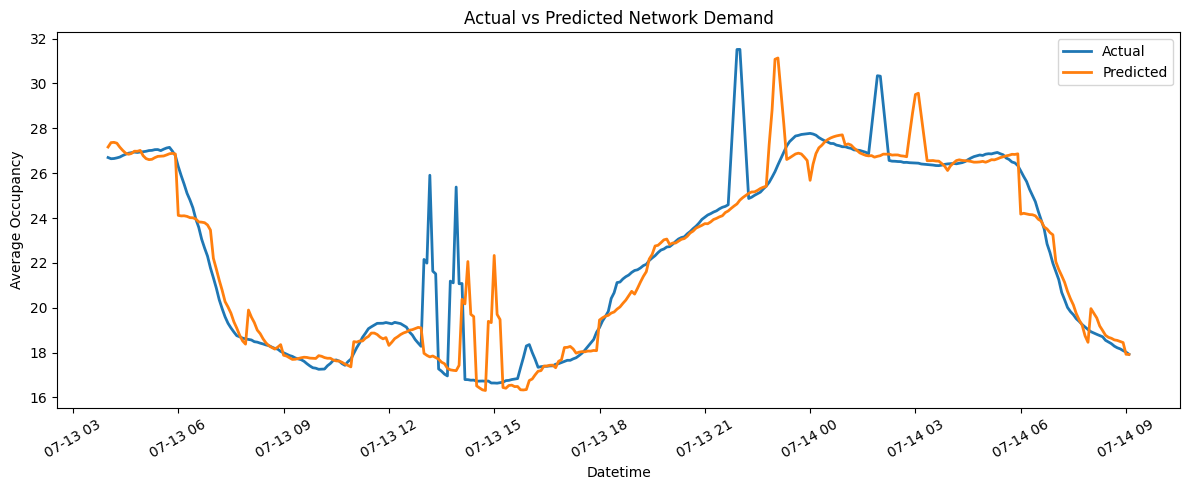

In [43]:
best_model_name = comparison.iloc[0]["model"]
test_eval["predicted_occupancy"] = predictions[best_model_name]
test_eval["prediction_error"] = test_eval["target"] - test_eval["predicted_occupancy"]
test_eval["predicted_utilization"] = (test_eval["predicted_occupancy"] / test_eval["count"]).clip(0, 1.5)

plot_df = (
    test_eval.groupby("datetime", as_index=False)
    .agg(actual=("target", "mean"), predicted=("predicted_occupancy", "mean"))
    .head(350)
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(plot_df["datetime"], plot_df["actual"], label="Actual", linewidth=2)
ax.plot(plot_df["datetime"], plot_df["predicted"], label="Predicted", linewidth=2)
ax.set_title("Actual vs Predicted Network Demand")
ax.set_xlabel("Datetime")
ax.set_ylabel("Average Occupancy")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / "actual_vs_predicted_demand.png", dpi=160)
fig


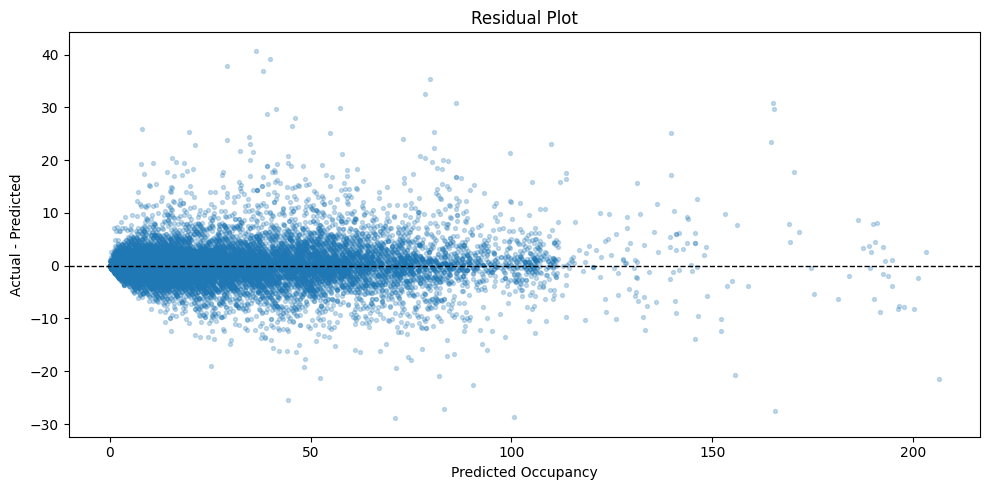

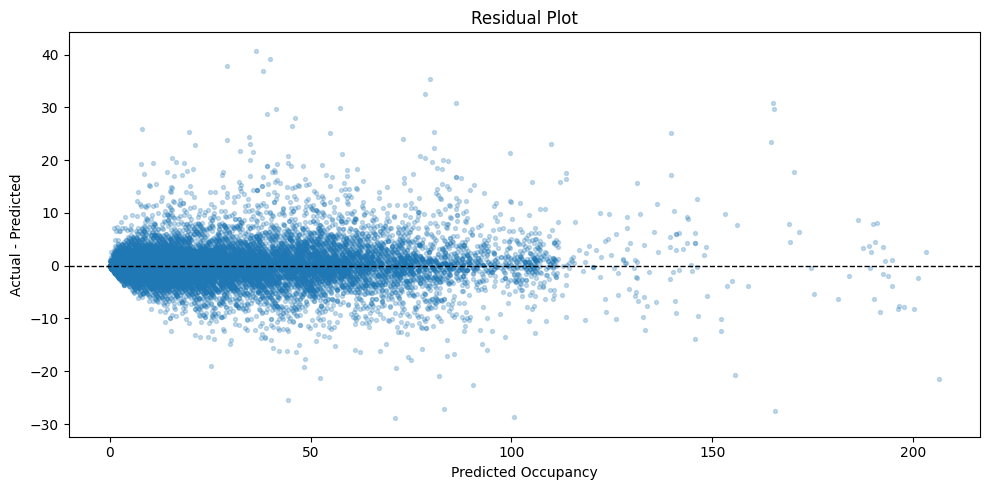

In [44]:
sample_residuals = test_eval.sample(n=min(25_000, len(test_eval)), random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(sample_residuals["predicted_occupancy"], sample_residuals["prediction_error"], alpha=0.25, s=8)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Residual Plot")
ax.set_xlabel("Predicted Occupancy")
ax.set_ylabel("Actual - Predicted")
plt.tight_layout()
plt.savefig(FIG_DIR / "residual_plot.png", dpi=160)
fig


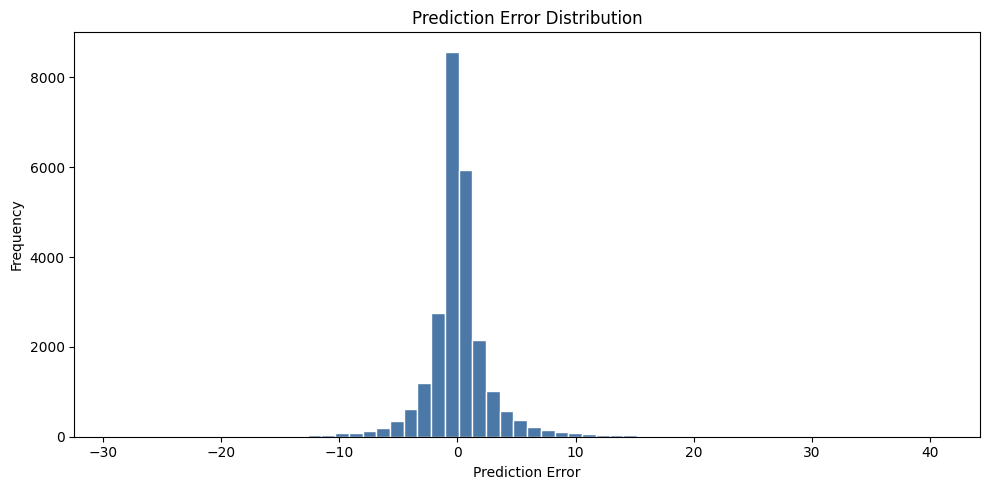

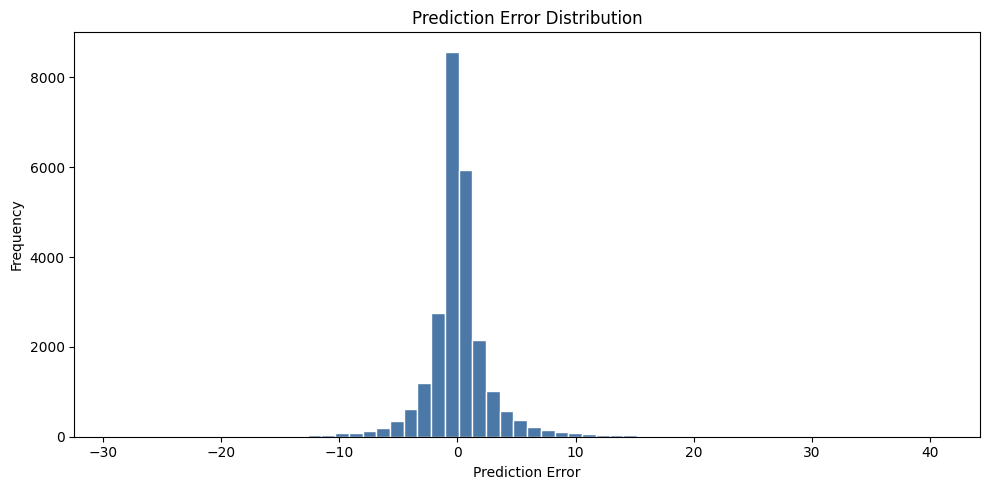

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sample_residuals["prediction_error"], bins=60, color="#4c78a8", edgecolor="white")
ax.set_title("Prediction Error Distribution")
ax.set_xlabel("Prediction Error")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIG_DIR / "prediction_error_distribution.png", dpi=160)
fig


### Business Interpretation

The actual-vs-predicted plot confirms whether the model follows the timing of network demand. The residual plots reveal whether errors are centered around zero or if the model systematically underestimates peak occupancy.


### Business Interpretation

Positive off-peak uplift indicates that discount pricing is shifting some demand into low-utilization windows, improving infrastructure use without adding new chargers.


## Dynamic Tariff Simulation for Demand-Side KPIs

The pricing rule converts predicted utilization into a tariff:

- Off-peak discount when utilization is below 30 percent
- Mild premium during normal periods
- Surge premium above 80 percent utilization

In [46]:
test_eval["rho_before"] = test_eval["predicted_utilization"].clip(0, 0.98)
test_eval["waiting_time_proxy_before"] = (
    test_eval["rho_before"] / (1 - test_eval["rho_before"])
)

peak_rows = test_eval[test_eval["predicted_utilization"] > 0.30]
print(f"Peak rows (util > 0.30): {len(peak_rows):,} / {len(test_eval):,}")
print(f"Mean M/M/1 proxy before pricing: {peak_rows['waiting_time_proxy_before'].mean():.4f}")

# Save predictions parquet — NB05 will add tariff columns on top
test_eval.to_parquet(REPORT_DIR / "demand_agent_predictions.parquet", index=False)
print("Saved demand_agent_predictions.parquet")

Peak rows (util > 0.30): 167,055 / 411,996
Mean M/M/1 proxy before pricing: 1.0346
Saved demand_agent_predictions.parquet


## Charger Utilization Rate KPI


In [47]:
# REPLACE Cell 22 with:
network_utilization = test_eval["predicted_utilization"].mean()

grid_utilization = (
    test_eval.groupby("grid", as_index=False)
    .agg(
        avg_utilization_before=("predicted_utilization", "mean"),
        charger_count=("count", "mean"),
    )
    .sort_values("avg_utilization_before", ascending=False)
)

peak_hour_utilization = (
    test_eval.groupby("hour", as_index=False)
    .agg(avg_utilization=("predicted_utilization", "mean"))
    .sort_values("avg_utilization", ascending=False)
)

utilization_dashboard = pd.DataFrame([
    {"metric": "Network utilization before pricing", "value": network_utilization},
    {"metric": "Peak utilization hour", "value": peak_hour_utilization.iloc[0]["hour"]},
])

grid_utilization.to_csv(REPORT_DIR / "grid_utilization_summary.csv", index=False)
peak_hour_utilization.to_csv(REPORT_DIR / "peak_hour_utilization.csv", index=False)
utilization_dashboard.to_csv(REPORT_DIR / "charger_utilization_dashboard.csv", index=False)
utilization_dashboard

,metric,value
0,Network utilization before pricing,0.287548
1,Peak utilization hour,0.000000


### Business Interpretation

Network utilization shows the overall efficiency of charger assets. Grid-level utilization identifies locations that need pricing intervention, infrastructure expansion, or operational monitoring.


## Export Forecasts For Pricing Agent

In [48]:
forecast_output = test_eval[
    [
        "grid",
        "datetime",
        "dayofweek",
        "hour",
        "predicted_occupancy",
        "predicted_utilization"
    ]
]

forecast_output.to_parquet(
    REPORT_DIR /
    "forecast_output.parquet",
    index=False
)

forecast_output.head()

,grid,datetime,dayofweek,hour,predicted_occupancy,predicted_utilization
1647984,1000,2022-07-13 04:00:00,2,4,68.238075,0.353565
1647985,1009,2022-07-13 04:00:00,2,4,81.706490,0.396633
1647986,1011,2022-07-13 04:00:00,2,4,102.587082,0.298218
1647987,1015,2022-07-13 04:00:00,2,4,26.770466,0.278859
1647988,102,2022-07-13 04:00:00,2,4,19.774317,0.659144


## Export Demand Agent KPI Summary


In [49]:
demand_accuracy = comparison.loc[comparison["model"] == best_model_name].iloc[0]

waiting_before = peak_rows["waiting_time_proxy_before"].mean()

demand_kpis = pd.DataFrame([
    {"KPI": "Demand Forecast Accuracy R2", "Value": demand_accuracy["R2"]},
    {"KPI": "Demand Forecast RMSE",        "Value": demand_accuracy["RMSE"]},
    {"KPI": "Charger Utilization Rate",    "Value": network_utilization},
    {"KPI": "Waiting Time Proxy Before",   "Value": waiting_before},   # NB05 uses this
])

demand_kpis.to_csv(REPORT_DIR / "demand_agent_kpis.csv", index=False)
demand_kpis

,KPI,Value
0,Demand Forecast Accuracy R2,0.984904
1,Demand Forecast RMSE,3.076585
2,Charger Utilization Rate,0.287548
3,Waiting Time Proxy Before,1.034598


## Limitations and Future Work

- The tariff response is simulated with an elasticity assumption, not observed behavior from a live dynamic-pricing experiment.
- Weather, events, holidays, grid load, and competitor prices are not included.
- Future work should validate elasticity with A/B tests, add exogenous variables, and retrain the agent on live outcomes.
